In [23]:
# Step_1 :Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
# Step_2 Create a dataset
data = {
    "Experience": [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    "Salary": [25000,28000,32000,36000,41000,46000,51000,56000,61000,67000,
               72000,78000,84000,90000,97000,103000,110000,117000,124000,130000]
}

df = pd.DataFrame(data)

print(df)

    Experience  Salary
0            1   25000
1            2   28000
2            3   32000
3            4   36000
4            5   41000
5            6   46000
6            7   51000
7            8   56000
8            9   61000
9           10   67000
10          11   72000
11          12   78000
12          13   84000
13          14   90000
14          15   97000
15          16  103000
16          17  110000
17          18  117000
18          19  124000
19          20  130000


In [25]:
# step_3: Separate Independent Variable (X) and Dependent Variable (y)

In [26]:
x = df[["Experience"]]
y = df["Salary"]

print("Independent variable (x): ")
print(x.head())

print("\nDependent Variable (y)")
print(y.head())

Independent variable (x): 
   Experience
0           1
1           2
2           3
3           4
4           5

Dependent Variable (y)
0    25000
1    28000
2    32000
3    36000
4    41000
Name: Salary, dtype: int64


In [27]:
# Step 4: Split the Dataset into Training and Testing Data

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data shpae:", x_train.shape)
print("Testing Data shape: ", x_test.shape)


Training Data shpae: (16, 1)
Testing Data shape:  (4, 1)


In [28]:
# Step 5: Create and Train the Linear Regression Model
model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
# Step 6: Make Predictions
y_pred = model.predict(x_test)

print("Predicted Salary: ")
print(y_pred.astype(int))

Predicted Salary: 
[ 16582 115082 103494  22376]


In [33]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values.flatten(),
    "Predicted Salary": y_pred.flatten()
})

print(comparison.astype(int))

   Actual Salary  Predicted Salary
0          25000             16582
1         117000            115082
2         103000            103494
3          28000             22376


In [34]:

comparison["Difference"] = abs(
    comparison["Actual Salary"] - comparison["Predicted Salary"]
)

print(comparison)

   Actual Salary  Predicted Salary   Difference
0          25000      16582.415925  8417.584075
1         117000     115082.943749  1917.056251
2         103000     103494.646358   494.646358
3          28000      22376.564621  5623.435379


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 4113.180515759314
MSE: 26599631.702508453
RMSE: 5157.483078257112
R2 Score: 0.9849608075465517


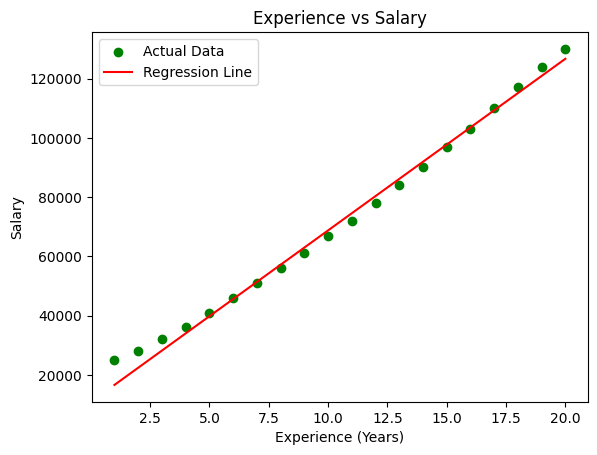

In [40]:
# Step 8: Plot the Regression Line
plt.scatter(x,y, color="green", label="Actual Data")
plt.plot(x, model.predict(x), color="red", label="Regression Line")

plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.legend()

plt.show()

In [54]:
# Step 9: Predict Salary for a New Experience
new_experience = [[12]]

predicted_salary = model.predict(new_experience)

print("Predicted Salary:", int(predicted_salary[0]))

Predicted Salary: 80318


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
